Dean Hickman

CS 251/2: Data Analysis and Visualization

# Lab 7 | Visualizing Radial Basis Function Neural Networks

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial import distance
from sklearn.cluster import KMeans



## Task 1: Load dataset and initialize variables

### 1a. Import Data

Below, using numpy [load](https://numpy.org/doc/stable/reference/generated/numpy.load.html) load in the sample data (`x_24.npy`) and class labels (`y_24.npy`). The dataset has 5000 samples.

In [6]:
x = np.load('data/x_24.npy')
y = np.load('data/y_24.npy')
print(x.shape)
print(y.shape)

(800, 2)
(800,)


### 1b. Create Clusters

In the RBF neural network, the number of neurons in the hidden layer will be `8`.

1. Create an instance of the [KMeans clustering algorithm class](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), with the number of clusters as the number of neurons in the hidden layer. Set the keyword argument `n_init` to `10` (*the number of times to run K-means*).
    1. Calculate the `cluster_assignments` by fitting the KMeans clustering algorithm to all samples (`x_24`).
    2. Assign the cluster centroids to the variable `prototypes`.  
2. Calculate the `sigmas` for each cluster, the sigma is the mean distance between a prototype and all the samples assigned to the same cluster.
    1. The length of `sigmas` array should be equal to the number of hidden neurons.
    2. In the lab (*but not the project*) you can use [cdist](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cdist.html) to compute distance between the centroid and the data samples assigned to it. `cdist` expects two 2D arrays, so you will need to make your prototype a 2D array.

In [7]:
# KEEP ME
np.random.seed(10)

kmean = KMeans(n_clusters=8, n_init=10)
predict = kmean.fit_predict(x)

prototypes = kmean.cluster_centers_

sigmas = np.zeros(8)
for i in range(8):
    cluster = x[predict == i]
    twod_prototypes = prototypes[i].reshape(1,-1)
    dist = distance.cdist(twod_prototypes, cluster)
    sigmas[i] = np.mean(dist)

### 1c. Visualize Clusters

1. Create a scatterplot of the training data with the x coordinates, y coordinates, coloring the points according to the class label.
2. On the same plot as the scatterplot. Draw the clusters
    1. For each cluster, draw a [circle](https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Circle.html) with the center at the prototype coordinates, using its sigma as the radius.  
    2. Add the circle to the axis. [add_patch](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.add_patch.html)
    3. Set the alpha of the circles to be partially transparent and the `facecolor` and `edgecolor` to something easily differentiated from the data.
3. Title the plot.

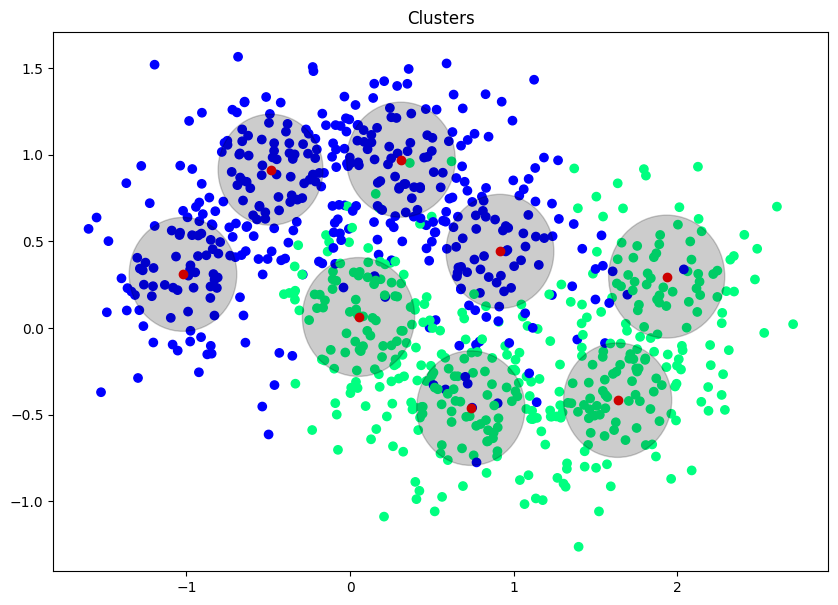

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(x[:,0], x[:,1], c = y, cmap = 'winter')
ax.scatter(prototypes[:,0], prototypes[:,1], marker = 'o', c = 'r')

for i in range(prototypes.shape[0]):
    circle = plt.Circle(xy  = (prototypes[i,0] , prototypes[i,1]), radius=sigmas[i])
    circle.set_alpha(0.2)
    circle.set_facecolor('black')
    circle.set_edgecolor('black')
    ax.add_patch(circle)

ax.set_title('Clusters')
plt.show()

## Task 2. Visualize Model

1. Create a scatter plot of the training data with the x coordinates, y coordinates, coloring the points using the class label.
2. On the same plot as the scatter plot, draw circles to represent the clusters and color them based on the resulting weights (`wts`) given below. *These are the already trained weights between the Hidden and Output layers of the RBF network.*
    1. For each cluster, draw a circle with the center at the prototype coordinates, using the sigma as the radius. 
    2. Set the alpha of the circles to be semi-transparent.
    3. Using the weights, determine whether each hidden neuron is most associated with the 1st or 2nd data class. The class associated with each neuron (each row of `wts`) is defined as the index of the column (class) that yields the greatest weight. Color the classes differently (*i.e. one of two colors*) with `facecolors` and a black `edgecolor`. Each of the `K` hidden neurons should have an associated class.
3. Title the plot.

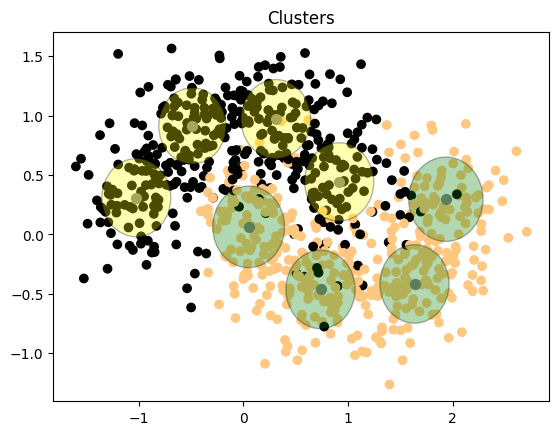

In [9]:
# KEEP ME
wts = np.array([[ 0.68767607, -0.68767607],
       [-0.46745546,  0.46745546],
       [-0.56568621,  0.56568621],
       [ 0.55736802, -0.55736802],
       [-0.45171637,  0.45171637],
       [ 0.62908217, -0.62908217],
       [-0.52861136,  0.52861136],
       [ 0.62172913, -0.62172913]])


class_colors = ['yellow', 'green']
fig, ax = plt.subplots()
ax.scatter(x[:,0], x[:,1], c =  y, cmap = 'copper')
ax.scatter(prototypes[:,0],prototypes[:,1], c ='grey', s = 50)

for i in range(prototypes.shape[0]):
    neuron_class = np.argmax(wts[i])
    circle = plt.Circle(xy=(prototypes[i, 0], prototypes[i, 1]), radius=sigmas[i], alpha=.3)
    circle.set_facecolor(class_colors[neuron_class])
    circle.set_edgecolor('black')
    ax.add_patch(circle)

ax.set_title('Clusters')
plt.show()
